In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df=pd.read_csv("energydata_complete.csv")
df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [3]:
df.isnull().sum()

date           0
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
# Select numerical columns only
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols=df.select_dtypes(include=['object']).columns

In [6]:
df.shape

(19735, 29)

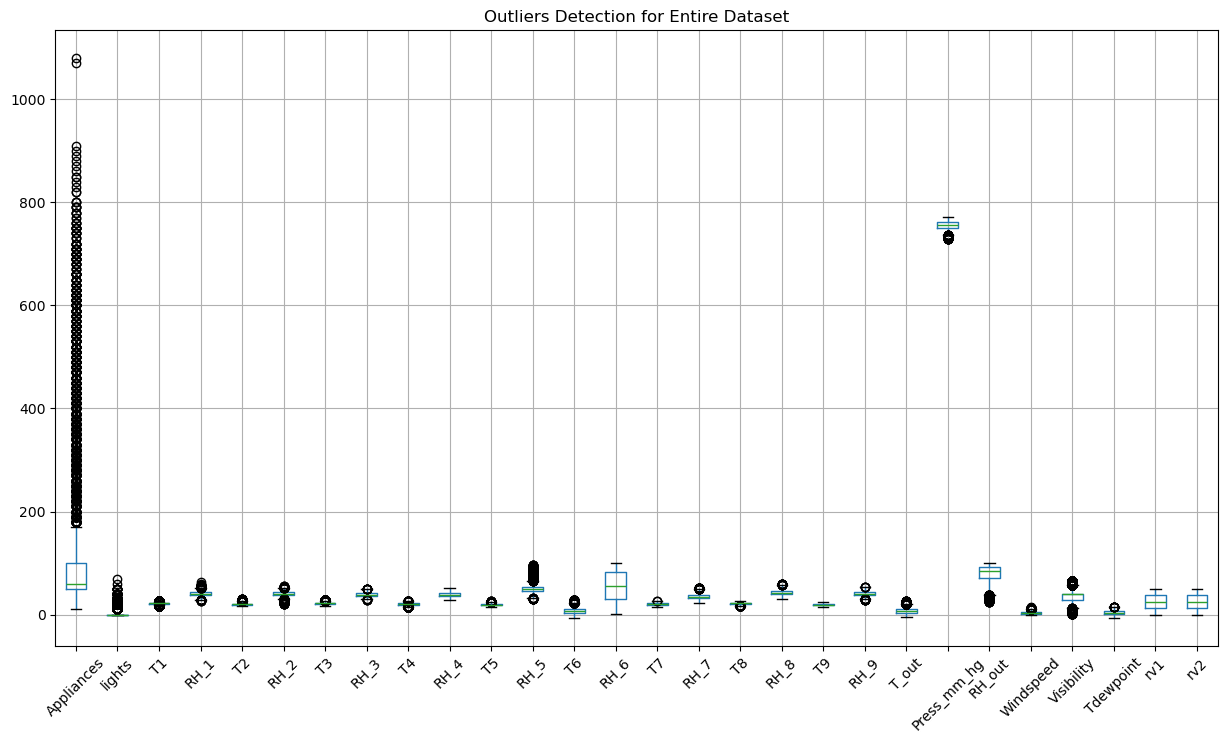

In [7]:
import matplotlib.pyplot as plt

# Select numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Create single figure
plt.figure(figsize=(15,8))

# Plot boxplots for all numerical columns
df[num_cols].boxplot()

plt.title("Outliers Detection for Entire Dataset")
plt.xticks(rotation=45)

plt.show()

In [8]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

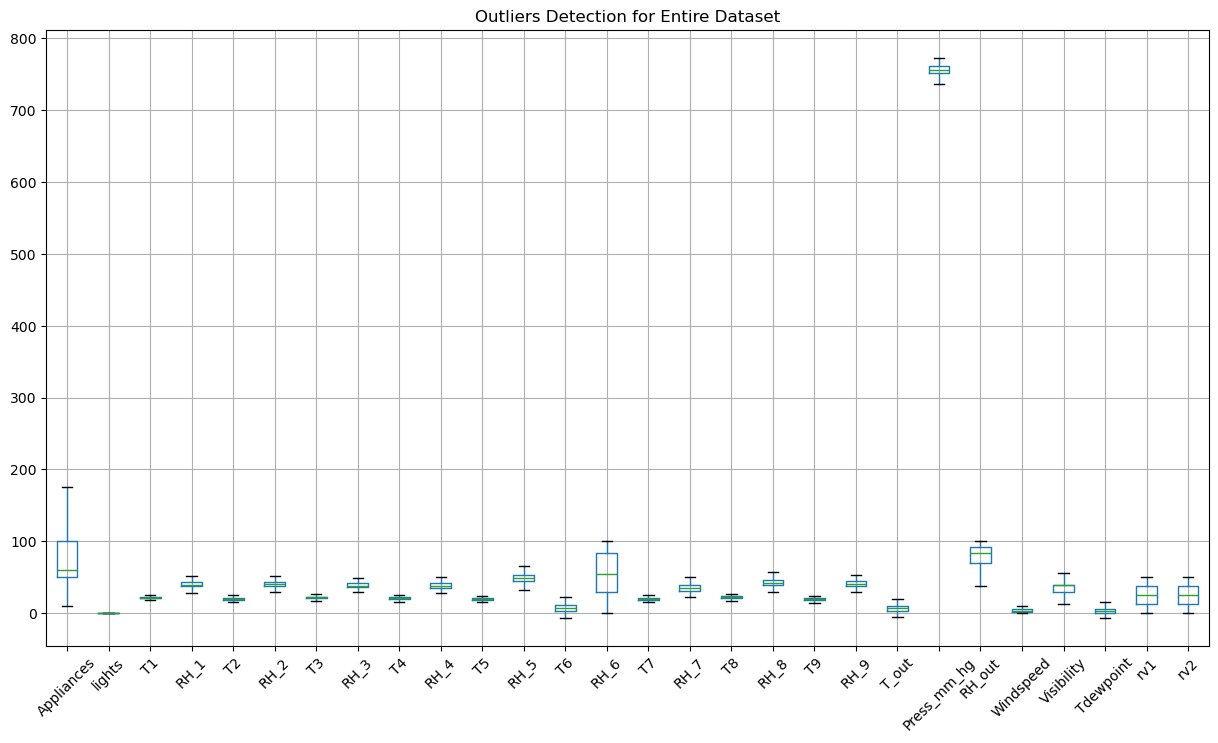

In [9]:

# Create single figure
plt.figure(figsize=(15,8))

# Plot boxplots for all numerical columns
df[num_cols].boxplot()

plt.title("Outliers Detection for Entire Dataset")
plt.xticks(rotation=45)

plt.show()

In [10]:
df.shape

(19735, 29)

In [11]:
x=df.drop(['Appliances','date','rv1','Tdewpoint'],axis=1)
x.columns

Index(['lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5',
       'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out',
       'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'rv2'],
      dtype='object')

In [12]:
y=df['Appliances']

In [13]:
# Select numerical columns only
num_cols = x.select_dtypes(include=['int64', 'float64']).columns
cat_cols=x.select_dtypes(include=['object']).columns
num_cols

Index(['lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5',
       'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out',
       'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'rv2'],
      dtype='object')

In [14]:
#apply columntransformer 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder,StandardScaler
ct=ColumnTransformer(transformers=[("oe",OrdinalEncoder(),cat_cols),
                                   ("sc",StandardScaler(),num_cols)])

In [15]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [16]:
x_train_tran=ct.fit_transform(x_train)
x_train_tran=pd.DataFrame(x_train_tran)

In [17]:
x_test_tran=ct.transform(x_test)
x_test_tran=pd.DataFrame(x_test_tran)

In [18]:
from sklearn.neighbors import KNeighborsRegressor
kn=KNeighborsRegressor(n_neighbors=5)
kn.fit(x_train_tran,y_train)

KNeighborsRegressor()

In [19]:
#predct
y_pred=kn.predict(x_test_tran)

In [20]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# predictions
y_pred = kn.predict(x_test_tran)

# R2 Score
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.5764943582258919


In [21]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'p': [1, 2]
}

# -----------------------------
# GRID SEARCH
# -----------------------------
grid = GridSearchCV(
    estimator=kn,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# -----------------------------
# TRAIN
# -----------------------------
grid.fit(x_train_tran, y_train)

# -----------------------------
best_knn = grid.best_estimator_

# -----------------------------
# PREDICTION
# -----------------------------
y_pred = best_knn.predict(x_test_tran)

# -----------------------------
# EVALUATION
# -----------------------------
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R2 Score :", r2)

R2 Score : 0.6981558773541099


In [27]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor(
    max_depth=143,
    random_state=42
)
model.fit(x_train_tran,y_train)

DecisionTreeRegressor(max_depth=143, random_state=42)

In [28]:
y_pred = model.predict(x_test_tran)
r2 = r2_score(y_test, y_pred)
r2

0.5151569542858434

In [29]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()

model.fit(x_train_tran, y_train)

GaussianNB()

In [30]:
y_pred = model.predict(x_test_tran)

In [31]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)

print("Accuracy :", acc)
print("Accuracy % :", acc * 100)

Accuracy : 0.13959969597162403
Accuracy % : 13.959969597162402
